# Transformer example

This notebook builds a tiny **Transformer** whose attention is
constrained by a named TF–TG edgelist.

The scientific motivation is prior-gated attention as in
[Milia et al., 2026](https://doi.org/10.48550/arXiv.2606.09558)
(DOI: [10.48550/arXiv.2606.09558](https://doi.org/10.48550/arXiv.2606.09558)).
That paper (scTransformer) puts curated transcription-factor to
target-gene edges into multi-head attention so a gene token may
mix only along known regulatory pairs. We do **not** reproduce
their dataset, metrics, or results. The point here is the same
building block: an edgelist becomes the allow-set of attention.

`kpnn2` does not ship a Transformer. You write the encoder, FFN,
residual, pooling, and head in PyTorch.
`PackedMultiheadAttention` is the primitive that scores only live
edgelist pairs. There is no `parse_attention()`.
`parse_adjacency()` already returns the packed indices.

It assumes you have already read
[Getting started](../getting-started/). That tutorial is a
feedforward `MaskedLinear` KPNN. Here every gene is a token and
the prior is an attention allow-set, not a hop mask.


In [1]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [2]:
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Define the graph

Two transcription-factor nodes gather from disjoint gene sets:

- `gene_signal_*` feed `tf_signal` (informative later)
- `gene_noise_*` feed `tf_noise` (uninformative later)

The edgelist format is the same two columns as
[Getting started](../getting-started/): `source` and `target`.
In `kpnn2`, a row means **source feeds target**. For attention
that is **query = target, key/value = source**, so `tf_signal`
attends to its signal genes. That matches the paper's "TF tokens
gather from their targets" story, and it is the same arrow as a
KPNN linear layer.

A CollecTRI-style table written as TF → TG is the opposite
column order. Swap `source` and `target` before parsing if you
want this gathering convention.

This graph is a DAG, so `parse_layered()` would accept it. Use
`parse_adjacency()` anyway: every node is one token in a single
sequence. Do not pass a hop mask to
`PackedMultiheadAttention`.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
        ],
        "target": [
            "tf_signal",
            "tf_signal",
            "tf_signal",
            "tf_noise",
            "tf_noise",
            "tf_noise",
        ],
    }
)

spec = kpnn2.parse_adjacency(edgelist)
edgelist

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise


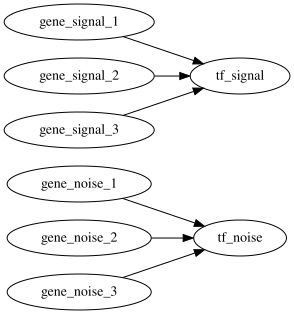

In [4]:
dot = Digraph()
dot.attr(rankdir="LR")

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.input_nodes:
        s.node(name, name)

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.output_nodes:
        s.node(name, name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

`parse_adjacency()` puts every node in one alphabetical sequence
and packs the live pairs. Genes are in-degree 0 (`input_nodes`).
TFs are out-degree 0 (`output_nodes`). Those roles are graph
structure, not "only genes are tokens": both are tokens. The
input role only tells us which columns `align_inputs()` returns.

`add_self_loops=True` below ORs missing `(i, i)` pairs into the
layer so isolated queries (the genes) are not forced to zero.
The paper also keeps self-loops. `need_weights=True` is
rejected: returning a dense `(L, S)` weight matrix is exactly
what this primitive must not allocate, so we will not plot
attention maps.


In [5]:
n_nodes = len(spec.nodes)
spec.nodes, spec.input_nodes, spec.output_nodes

(('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3',
  'tf_noise',
  'tf_signal'),
 ('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'),
 ('tf_noise', 'tf_signal'))

## Write a Transformer around PackedMultiheadAttention

The encoder is ordinary PyTorch: expression projection, a learned
identity embedding per named node, Pre-LN packed attention, a
token-wise FFN, and residuals. The classification head reads only
the TF tokens (`spec.output_index`), as in the paper's pooling
over regulators.

`align_inputs()` is still the gene table helper. It is
`len(input_nodes)` wide, not `n_nodes` wide. Scatter those
columns into the token sequence with `spec.input_index` before
attention. TF positions stay zero: they are not measured
features; they gather gene values through the prior.


In [6]:
class TokenEncoder(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int,
        num_heads: int,
    ):
        super().__init__()
        self.spec = spec
        n_nodes = len(spec.nodes)
        self.expr_proj = nn.Linear(
            1,
            embed_dim,
        )
        self.id_embed = nn.Embedding(
            n_nodes,
            embed_dim,
        )
        self.attn = kpnn2.PackedMultiheadAttention(
            spec.source_index,
            spec.target_index,
            n_nodes,
            n_nodes,
            embed_dim,
            num_heads,
            add_self_loops=True,
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(
                embed_dim,
                2 * embed_dim,
            ),
            nn.ReLU(),
            nn.Linear(
                2 * embed_dim,
                embed_dim,
            ),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        n_nodes = len(self.spec.nodes)
        tokens = self.expr_proj(x.unsqueeze(-1))
        node_ids = torch.arange(
            n_nodes,
            device=x.device,
        )
        tokens = tokens + self.id_embed(node_ids)
        normed = self.norm1(tokens)
        attended, _ = self.attn(
            normed,
            normed,
            normed,
        )
        tokens = tokens + attended
        tokens = tokens + self.ffn(self.norm2(tokens))
        return tokens


class PriorTransformer(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int = 8,
        num_heads: int = 2,
    ):
        super().__init__()
        self.spec = spec
        self.encoder = TokenEncoder(
            spec,
            embed_dim,
            num_heads,
        )
        n_tf = len(spec.output_index)
        self.head = nn.Linear(
            n_tf * embed_dim,
            1,
        )

    def forward(self, x_genes):
        n_nodes = len(self.spec.nodes)
        state = x_genes.new_zeros(
            x_genes.shape[0],
            n_nodes,
        )
        state[:, self.spec.input_index] = x_genes
        encoded = self.encoder(state)
        tf_tokens = encoded[:, self.spec.output_index]
        pooled = tf_tokens.reshape(
            tf_tokens.shape[0],
            -1,
        )
        return self.head(pooled)

In [7]:
model = PriorTransformer(spec)
(
    n_nodes,
    model.encoder.attn.nnz,
    spec.source_index,
    spec.target_index,
)

(8, 14, (0, 1, 2, 3, 4, 5), (6, 6, 6, 7, 7, 7))

## Simulate data, align genes, and train

Same binary toy as [Getting started](../getting-started/):
`gene_signal_*` change mean between classes, `gene_noise_*` do
not. 100 cells per class for training, 50 for testing.


In [8]:
informative_features = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]
noise_features = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50
rng = np.random.default_rng(42)


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]
    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")
    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)
x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

x_train = kpnn2.align_inputs(x_train_df, spec)
x_test = kpnn2.align_inputs(x_test_df, spec)
display(x_train_df.head())
x_train.shape, x_test.shape, len(spec.nodes)

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,-0.695943,-0.223859,0.242497,-1.139429,-0.481241,1.437777
1,3.068472,2.232878,2.234401,-0.712102,1.370541,-0.484030
2,-0.471525,0.263717,0.052467,0.288917,1.244947,-0.431339
3,0.941464,1.874991,3.481456,-0.109727,-0.035611,-1.364742
4,-0.926576,-0.389810,-1.376686,-1.119536,0.447814,0.058274


(torch.Size([200, 6]), torch.Size([100, 6]), 8)

Loss before first update: 0.7442
Loss after final update:  0.0834
Test accuracy: 0.89


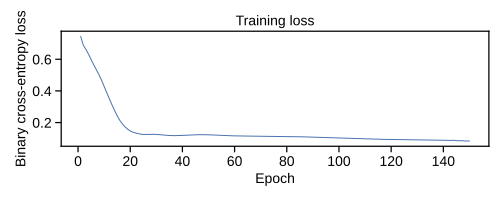

In [9]:
y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    pred = (torch.sigmoid(model(x_test))[:, 0] > 0.5).float()
    y_test_tensor = torch.tensor(
        y_test.values,
        dtype=torch.float32,
    )
    test_acc = float((pred == y_test_tensor).float().mean())

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)
print("Test accuracy:", round(test_acc, 3))

_new_fig(2.8)
plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret named nodes

`kpnn2` does not wrap Captum. Feature scores use
`IntegratedGradients` on the gene tensor from `align_inputs()`.
Node scores use `LayerConductance` on the encoder, whose output
is `(batch, n_nodes, embed_dim)`. Sum the embed axis so the
remaining width is `spec.nodes`, then
`map_node_attributions()` (no `layer=`: this is an
`AdjacencySpec`). See
[Mapping attributions](../map-node-attributions/).

Gene tokens are not read by the head, so encoder conductance on
those positions is zero. The TF tokens should not be: `tf_signal`
gathers the informative genes.


In [10]:
from captum.attr import (
    IntegratedGradients,
    LayerConductance,
)

model.eval()
ig = IntegratedGradients(model)
feature_tensor = ig.attribute(
    x_test,
    target=0,
)
feature_attr = pd.DataFrame(
    feature_tensor.detach().cpu().numpy(),
    columns=spec.input_nodes,
)
feature_summary = (
    feature_attr.abs()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
feature_summary

,mean_abs_attribution
gene_signal_3,2.975886
gene_signal_1,1.224089
gene_signal_2,1.036166
gene_noise_2,0.458086
gene_noise_1,0.074802
gene_noise_3,0.056345


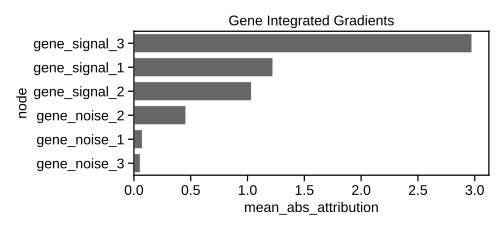

In [11]:
_new_fig(3.2)
ax = sns.barplot(
    data=feature_summary.reset_index().rename(columns={"index": "node"}),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Gene Integrated Gradients")
plt.tight_layout()
plt.show()

In [12]:
conductor = LayerConductance(
    model,
    model.encoder,
)
token_attr = conductor.attribute(
    x_test,
    target=0,
)
node_scores = token_attr.detach().abs().sum(dim=-1)
node_attr = kpnn2.map_node_attributions(
    attributions=node_scores,
    spec=spec,
)
node_summary = (
    node_attr.to_pandas()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
node_summary

,mean_abs_attribution
node,
tf_signal,4.813887
tf_noise,0.588435
gene_noise_1,0.000000
gene_noise_2,0.000000
gene_signal_1,0.000000
gene_noise_3,0.000000
gene_signal_3,0.000000
gene_signal_2,0.000000


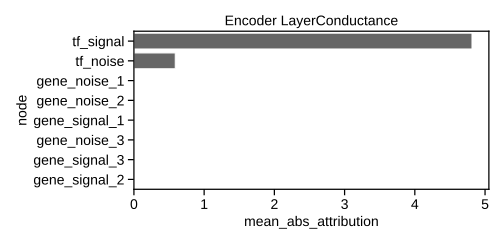

In [13]:
_new_fig(3.4)
ax = sns.barplot(
    data=node_summary.reset_index(),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Encoder LayerConductance")
plt.tight_layout()
plt.show()

## Control: rewire the prior

Keep the same cells and labels. Point the signal genes at
`tf_noise` and the noise genes at `tf_signal`. If the named
graph is the inductive bias, `tf_noise` should now carry the
task.


In [14]:
rewired = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
        ],
        "target": [
            "tf_noise",
            "tf_noise",
            "tf_noise",
            "tf_signal",
            "tf_signal",
            "tf_signal",
        ],
    }
)
rewired_spec = kpnn2.parse_adjacency(rewired)
torch.manual_seed(42)
rewired_model = PriorTransformer(rewired_spec)

optimizer = torch.optim.Adam(
    rewired_model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
rewired_model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = rewired_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

rewired_model.eval()
rewired_scores = (
    LayerConductance(
        rewired_model,
        rewired_model.encoder,
    )
    .attribute(
        x_test,
        target=0,
    )
    .detach()
    .abs()
    .sum(dim=-1)
)
rewired_summary = (
    kpnn2.map_node_attributions(
        attributions=rewired_scores,
        spec=rewired_spec,
    )
    .to_pandas()
    .mean()
    .rename("rewired")
)
compare = pd.concat(
    [
        node_summary["mean_abs_attribution"].rename("original"),
        rewired_summary,
    ],
    axis=1,
).loc[["tf_signal", "tf_noise"]]
compare

,original,rewired
node,,
tf_signal,4.813887,0.256008
tf_noise,0.588435,5.501344


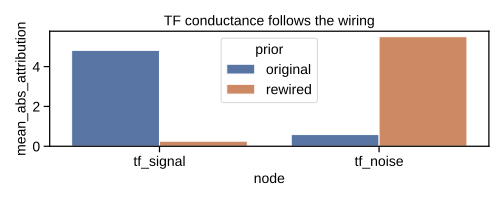

In [15]:
plot_df = compare.reset_index().melt(
    id_vars="node",
    var_name="prior",
    value_name="mean_abs_attribution",
)
_new_fig(2.8)
ax = sns.barplot(
    data=plot_df,
    x="node",
    y="mean_abs_attribution",
    hue="prior",
)
_style_ax(ax)
ax.set_title("TF conductance follows the wiring")
plt.tight_layout()
plt.show()

## What this page leaves out

Milia et al. train on a large snRNA-seq atlas with CollecTRI,
variable-length expressed-gene tokens, CSR batching, sinusoidal
expression encodings, and attention-map metrics. None of that is
in `kpnn2`, and none of it is repeated here.

`key_padding_mask` is the analogue of "this gene is not
expressed in this cell": a boolean mask over keys, applied in
packed space. Host-sparse storage (AnnData `.X`) stays in the
caller's loop; tensors that enter the module are dense.

`PackedLinear` is a different primitive (one scalar per edge,
not attention). See [PackedLinear](../packed_linear/) when the
adjacency square would hurt RAM, and the
[Cyclic graph example](../cyclic-graph-example/) for a cyclic
`MaskedLinear` state update. The API page is
[PackedMultiheadAttention](../reference/PackedMultiheadAttention/).
